# Discovery 1: What does the revenue landscape look like?

Exploratory analysis of daily revenue across Singapore hawker stalls — summary statistics, distribution shape, and breakdowns by location and cuisine type.

In [72]:
library(e1071)

par(bg = "white")

hawker_data <- read.csv("Hawker Data Statistics.csv")
str(hawker_data)
head(hawker_data)

'data.frame':	500 obs. of  7 variables:
 $ daily_revenue: num  113.5 234.3 211.4 144.7 96.4 ...
 $ avg_price    : num  5.95 6.11 3.17 4.16 5.35 4.42 8.48 7.94 4.05 5.04 ...
 $ location_type: chr  "CBD" "CBD" "HDB" "HDB" ...
 $ cuisine_type : chr  "Chinese" "Chinese" "Malay" "Chinese" ...
 $ competition  : int  13 8 11 8 7 12 8 9 4 7 ...
 $ day_type     : chr  "Weekend" "Weekday" "Weekend" "Weekday" ...
 $ stall_age    : num  5.9 18.3 6.8 20.3 26.9 26.1 24.7 11.5 18.5 18.7 ...


,daily_revenue,avg_price,location_type,cuisine_type,competition,day_type,stall_age
,<dbl>,<dbl>,<chr>,<chr>,<int>,<chr>,<dbl>
1,113.45,5.95,CBD,Chinese,13,Weekend,5.9
2,234.35,6.11,CBD,Chinese,8,Weekday,18.3
3,211.44,3.17,HDB,Malay,11,Weekend,6.8
4,144.72,4.16,HDB,Chinese,8,Weekday,20.3
5,96.40,5.35,HDB,Indian,7,Weekday,26.9
6,84.99,4.42,HDB,Malay,12,Weekend,26.1


In [73]:
# --- Summary statistics ---
cat("Mean:  ", mean(hawker_data$daily_revenue), "\n")
cat("Median:", median(hawker_data$daily_revenue), "\n")
cat("SD:    ", sd(hawker_data$daily_revenue), "\n")
cat("Var:   ", var(hawker_data$daily_revenue), "\n")
cat("Range: ", range(hawker_data$daily_revenue), "\n")
cat("IQR:   ", IQR(hawker_data$daily_revenue), "\n")
summary(hawker_data$daily_revenue)

Mean:   156.9886 
Median: 147.955 
SD:     61.11112 
Var:    3734.569 
Range:  43.93 486.54 
IQR:    71.8725 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  43.93  115.32  147.96  156.99  187.19  486.54 

In [74]:
# --- Check skewness (justifies log transformation later) ---
skewness(hawker_data$daily_revenue)

[1] 1.306964

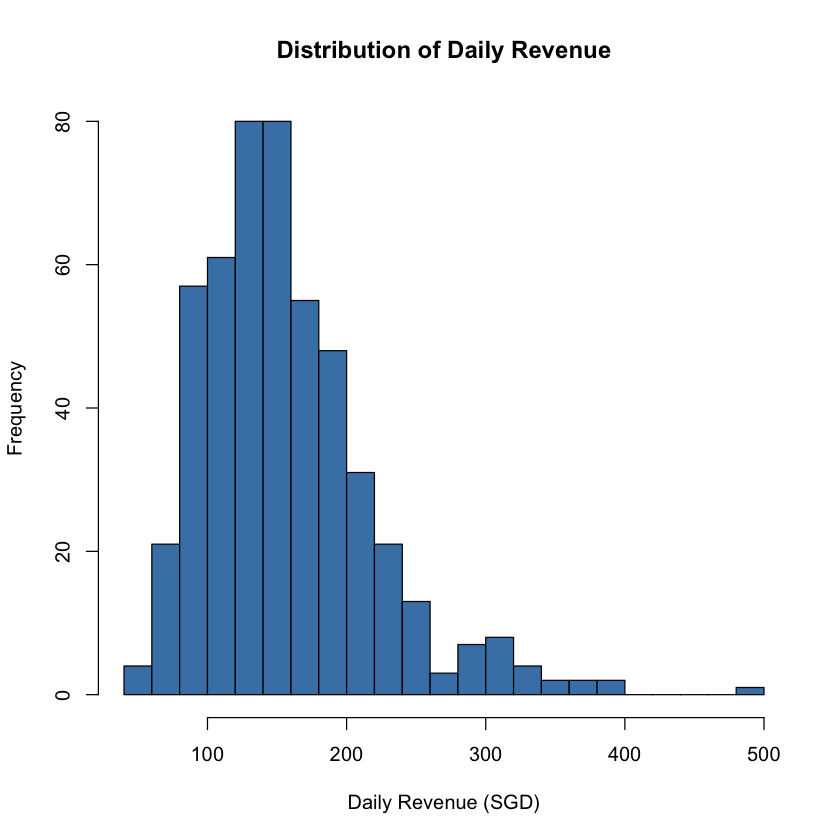

In [75]:
# --- Histogram of daily revenue ---
par(bg = "white")
hist(hawker_data$daily_revenue,
     breaks = 30,
     col = "steelblue",
     main = "Distribution of Daily Revenue",
     xlab = "Daily Revenue (SGD)",
     ylab = "Frequency")

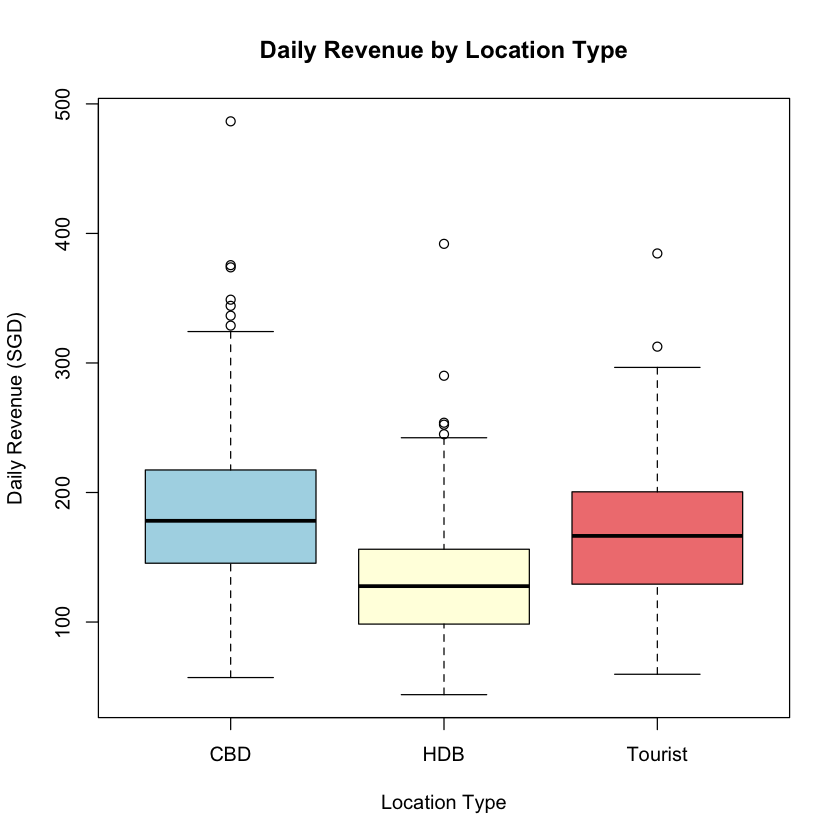

In [76]:
par(bg = "white")
# --- Box plot by location type ---
boxplot(daily_revenue ~ location_type,
        data = hawker_data,
        col = c("lightblue", "lightyellow", "lightcoral"),
        main = "Daily Revenue by Location Type",
        xlab = "Location Type",
        ylab = "Daily Revenue (SGD)")

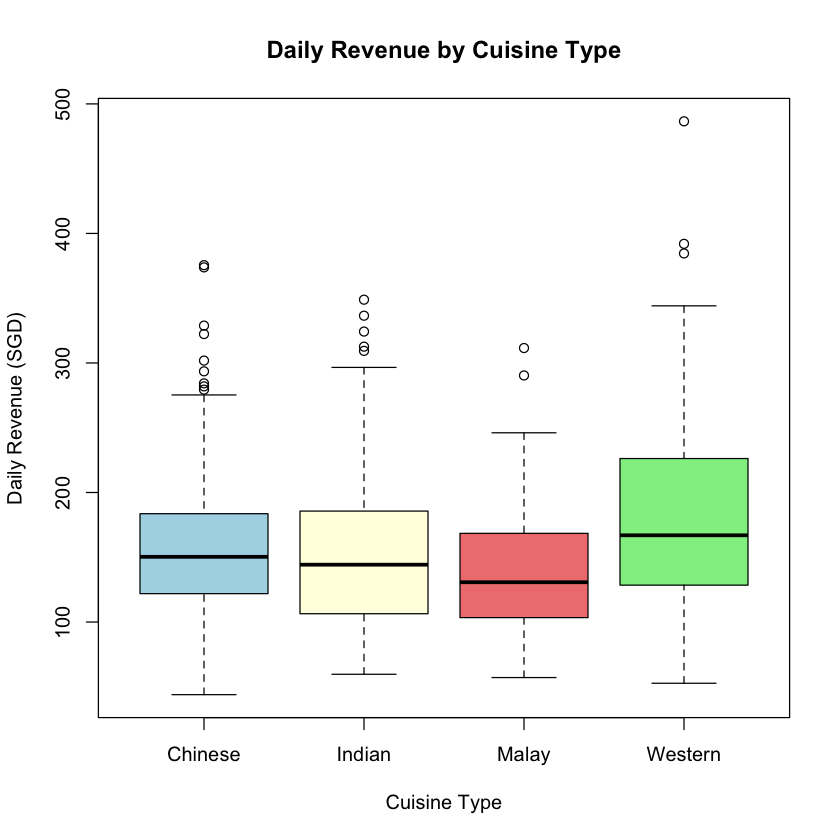

In [77]:
par(bg = "white")
# --- Box plot by cuisine type ---
boxplot(daily_revenue ~ cuisine_type,
        data = hawker_data,
        col = c("lightblue", "lightyellow", "lightcoral", "lightgreen"),
        main = "Daily Revenue by Cuisine Type",
        xlab = "Cuisine Type",
        ylab = "Daily Revenue (SGD)")

# Discovery 2: The Paradox — Price vs Revenue Correlation

Higher prices seem to correlate with MORE revenue. Color-coding by location reveals the confounding variable.

In [78]:
# --- Correlation between price and revenue ---
cor(hawker_data$avg_price, hawker_data$daily_revenue)

[1] 0.2606273

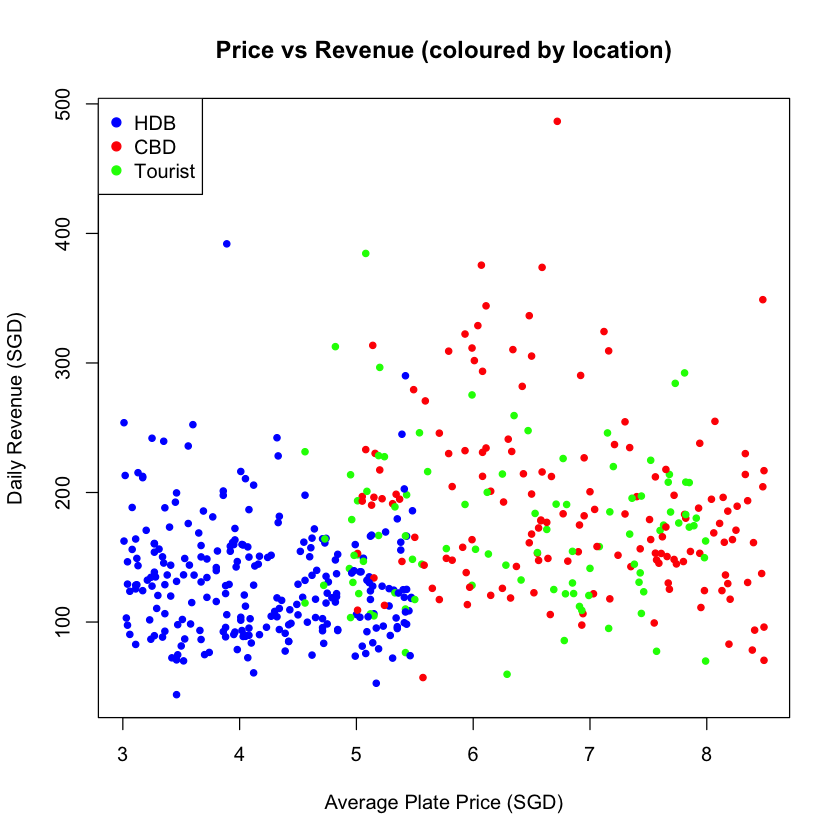

In [79]:
par(bg = "white")
# --- Scatter plot showing the paradox ---
colors <- ifelse(hawker_data$location_type == "HDB", "blue",
          ifelse(hawker_data$location_type == "CBD", "red", "green"))

plot(hawker_data$avg_price, hawker_data$daily_revenue,
     col = colors,
     pch = 19,
     cex = 0.7,
     main = "Price vs Revenue (coloured by location)",
     xlab = "Average Plate Price (SGD)",
     ylab = "Daily Revenue (SGD)")
legend("topleft",
       legend = c("HDB", "CBD", "Tourist"),
       col = c("blue", "red", "green"),
       pch = 19)

In [80]:
# --- Full correlation matrix for continuous variables ---
continuous_vars <- hawker_data[, c("daily_revenue", "avg_price",
                                    "competition", "stall_age")]
cor(continuous_vars)

,daily_revenue,avg_price,competition,stall_age
daily_revenue,1.0000000,0.26062728,-0.15416289,0.11773379
avg_price,0.2606273,1.00000000,0.03989876,0.01097994
competition,-0.1541629,0.03989876,1.00000000,0.03115186
stall_age,0.1177338,0.01097994,0.03115186,1.00000000


# Discovery 3: Multiple Regression — The True Price Effect

Since skewness > +1, we use `log(daily_revenue)` as the dependent variable. After controlling for location, cuisine, competition, day type, and stall age, the **true** effect of price on revenue is revealed.

## The Simpson's Paradox

The correlation matrix above shows a **positive** raw correlation between `avg_price` and `daily_revenue` (~0.26). At first glance, this suggests that higher prices lead to higher revenue.

However, this is misleading. The scatter plot colour-coded by location reveals the confounding: **CBD and Tourist stalls** naturally charge higher prices *and* earn higher revenue due to their location advantage (higher foot traffic, wealthier customers). Within each location type, the relationship between price and revenue is actually **negative** — stalls that charge more within the same area tend to lose customers and earn less.

This is a classic case of **Simpson's Paradox**: the direction of an association reverses when a confounding variable (location) is controlled for. The multiple regression in Discovery 3 will confirm this by showing a **negative** price coefficient once location and other confounders are held constant.

In [81]:
# --- Check skewness again to justify log transform ---
skewness(hawker_data$daily_revenue)

[1] 1.306964

In [82]:
# --- Convert categorical variables to factors ---
hawker_data$location_type <- factor(hawker_data$location_type,
                                     levels = c("HDB", "CBD", "Tourist"))
hawker_data$cuisine_type  <- factor(hawker_data$cuisine_type,
                                     levels = c("Chinese", "Malay",
                                                "Indian", "Western"))

In [83]:
# --- Run the regression ---
reg_results <- lm(log(daily_revenue) ~ avg_price + location_type +
                    cuisine_type + competition + day_type + stall_age,
                  data = hawker_data)

summary(reg_results)


Call:
lm(formula = log(daily_revenue) ~ avg_price + location_type + 
    cuisine_type + competition + day_type + stall_age, data = hawker_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.10210 -0.20625  0.00532  0.22030  0.79825 

Coefficients:
                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)           5.080416   0.083336  60.963  < 2e-16 ***
avg_price            -0.049168   0.015237  -3.227 0.001335 ** 
location_typeCBD      0.481575   0.051344   9.379  < 2e-16 ***
location_typeTourist  0.380675   0.049910   7.627 1.26e-13 ***
cuisine_typeMalay    -0.086134   0.034731  -2.480 0.013474 *  
cuisine_typeIndian   -0.047972   0.038020  -1.262 0.207637    
cuisine_typeWestern   0.162443   0.042279   3.842 0.000138 ***
competition          -0.021049   0.004941  -4.260 2.45e-05 ***
day_typeWeekend       0.157104   0.029940   5.247 2.30e-07 ***
stall_age             0.005241   0.001638   3.200 0.001461 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01

In [84]:
# --- Store coefficients for the simulation later ---
coefs <- coef(reg_results)
sigma_hat <- summary(reg_results)$sigma
print(coefs)
print(sigma_hat)

         (Intercept)            avg_price     location_typeCBD 
         5.080415774         -0.049168305          0.481574894 
location_typeTourist    cuisine_typeMalay   cuisine_typeIndian 
         0.380675427         -0.086133545         -0.047972454 
 cuisine_typeWestern          competition      day_typeWeekend 
         0.162443017         -0.021048985          0.157104466 
           stall_age 
         0.005241395 
[1] 0.3075308


## Interpreting the Regression Results

Since the dependent variable is `log(daily_revenue)`, each coefficient is interpreted in **percentage** terms: a one-unit increase in a predictor is associated with approximately a `(coefficient × 100)%` change in daily revenue, holding all else constant.

**Reference categories:**
- **Location:** HDB (the baseline — CBD and Tourist are compared against HDB)
- **Cuisine:** Chinese (the baseline — Malay, Indian, and Western are compared against Chinese)

**Key coefficient interpretations:**
- `avg_price = -0.049`: A $1 increase in average plate price is associated with approximately a **4.9% decrease** in daily revenue, after controlling for location, cuisine, competition, day type, and stall age.
- `location_typeCBD = +0.482`: CBD stalls earn approximately **48.2% more** daily revenue than HDB stalls, all else equal.
- `location_typeTourist = +0.381`: Tourist-area stalls earn approximately **38.1% more** than HDB stalls.
- `competition = -0.021`: Each additional competing stall reduces daily revenue by approximately **2.1%**.
- `day_typeWeekend = +0.157`: Weekend revenue is approximately **15.7% higher** than weekday revenue.
- `stall_age = +0.005`: Each additional year of stall age is associated with approximately **0.5% higher** revenue (experience effect).
- `R-squared = 0.32`: The model explains about **32%** of the variation in log(daily_revenue).

# Discovery 4: Is the Price Effect Statistically Significant?

Formal hypothesis test for the price coefficient from the regression. We extract the t-statistic and p-value to test whether price has a real effect on revenue after controlling for confounders.

In [85]:
# --- Extract full coefficient table ---
summary(reg_results)$coefficients

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),5.080415774,0.083336088,60.962974,6.625492e-231
avg_price,-0.049168305,0.015237023,-3.226897,1.335158e-03
location_typeCBD,0.481574894,0.051344021,9.379376,2.462408e-19
location_typeTourist,0.380675427,0.049910186,7.627209,1.257574e-13
cuisine_typeMalay,-0.086133545,0.034731428,-2.479989,1.347361e-02
cuisine_typeIndian,-0.047972454,0.038020412,-1.261755,2.076372e-01
cuisine_typeWestern,0.162443017,0.042279469,3.842125,1.380085e-04
competition,-0.021048985,0.004941377,-4.259741,2.454644e-05
day_typeWeekend,0.157104466,0.029939772,5.247350,2.301579e-07
stall_age,0.005241395,0.001637717,3.200428,1.461261e-03


In [86]:
# --- Formal hypothesis test for avg_price ---
# H0: beta_price = 0 (price has no effect on revenue)
# H1: beta_price != 0 (price has an effect)
# Decision rule: reject H0 if p-value < 0.05

price_row <- summary(reg_results)$coefficients["avg_price", ]
cat("Price coefficient:", round(price_row["Estimate"], 4), "\n")
cat("t-statistic:", round(price_row["t value"], 4), "\n")
cat("p-value:", format(price_row["Pr(>|t|)"], scientific = TRUE), "\n")

Price coefficient: -0.0492 
t-statistic: -3.2269 
p-value: 1.335158e-03 


# Discovery 5: Monte Carlo Simulation — What If Prices Change?

We simulate revenue for representative stall profiles (HDB Chinese and CBD Chinese) under different price increase scenarios (+5%, +10%, +15%) using the regression coefficients from Discovery 3.

In [87]:
set.seed(2024)
n_sim <- 1000

# --- Baseline values for an HDB Chinese stall ---
base_price <- 3.50
base_competition <- 8
base_stall_age <- 10

# --- Pre-generate common random numbers (shared across all scenarios) ---
epsilon_sim <- rnorm(n_sim, 0, sigma_hat)
day_sim     <- sample(c(0, 1), n_sim, replace = TRUE, prob = c(5/7, 2/7))

# --- Function to simulate revenue using common random numbers ---
simulate_revenue <- function(price, coefs, epsilon_sim, day_sim,
                             location_offset = 0) {
  log_rev <- coefs["(Intercept)"] +
    coefs["avg_price"] * price +
    location_offset +
    coefs["competition"] * base_competition +
    coefs["day_typeWeekend"] * day_sim +
    coefs["stall_age"] * base_stall_age +
    epsilon_sim

  return(exp(log_rev))
}

In [88]:
# --- Simulate baseline and price increase scenarios (HDB) ---
rev_baseline <- simulate_revenue(base_price, coefs, epsilon_sim, day_sim)
rev_5pct  <- simulate_revenue(base_price * 1.05, coefs, epsilon_sim, day_sim)
rev_10pct <- simulate_revenue(base_price * 1.10, coefs, epsilon_sim, day_sim)
rev_15pct <- simulate_revenue(base_price * 1.15, coefs, epsilon_sim, day_sim)

pct_change_5  <- (rev_5pct - rev_baseline) / rev_baseline * 100
pct_change_10 <- (rev_10pct - rev_baseline) / rev_baseline * 100
pct_change_15 <- (rev_15pct - rev_baseline) / rev_baseline * 100

# --- Results: mean and 95% CI ---
results_table <- function(label, pct_change) {
  m   <- mean(pct_change)
  s   <- sd(pct_change)
  n   <- length(pct_change)
  LL  <- m - qt(0.975, n - 1) * s / sqrt(n)
  UL  <- m + qt(0.975, n - 1) * s / sqrt(n)
  cat(label, "\n")
  cat("  Mean change: ", round(m, 2), "%\n")
  cat("  95% CI:      [", round(LL, 2), "%, ", round(UL, 2), "%]\n\n")
}

cat("=== HDB Chinese Stall (baseline price: $3.50) ===\n\n")
results_table("+5% price increase ($3.68)", pct_change_5)
results_table("+10% price increase ($3.85)", pct_change_10)
results_table("+15% price increase ($4.03)", pct_change_15)

=== HDB Chinese Stall (baseline price: $3.50) ===



+5% price increase ($3.68) 
  Mean change:  -0.86 %
  95% CI:      [ -0.86 %,  -0.86 %]

+10% price increase ($3.85) 
  Mean change:  -1.71 %
  95% CI:      [ -1.71 %,  -1.71 %]

+15% price increase ($4.03) 
  Mean change:  -2.55 %
  95% CI:      [ -2.55 %,  -2.55 %]



In [89]:
# --- Repeat for a CBD stall (use location_offset for CBD coefficient) ---
base_price_CBD <- 5.00
cbd_offset     <- coefs["location_typeCBD"]

rev_baseline_CBD <- simulate_revenue(base_price_CBD, coefs, epsilon_sim, day_sim,
                                     location_offset = cbd_offset)
rev_5pct_CBD  <- simulate_revenue(base_price_CBD * 1.05, coefs, epsilon_sim, day_sim,
                                  location_offset = cbd_offset)
rev_10pct_CBD <- simulate_revenue(base_price_CBD * 1.10, coefs, epsilon_sim, day_sim,
                                  location_offset = cbd_offset)
rev_15pct_CBD <- simulate_revenue(base_price_CBD * 1.15, coefs, epsilon_sim, day_sim,
                                  location_offset = cbd_offset)

pct_change_5_CBD  <- (rev_5pct_CBD - rev_baseline_CBD) / rev_baseline_CBD * 100
pct_change_10_CBD <- (rev_10pct_CBD - rev_baseline_CBD) / rev_baseline_CBD * 100
pct_change_15_CBD <- (rev_15pct_CBD - rev_baseline_CBD) / rev_baseline_CBD * 100

cat("\n=== CBD Chinese Stall (baseline price: $5.00) ===\n\n")
results_table("+5% price increase ($5.25)", pct_change_5_CBD)
results_table("+10% price increase ($5.50)", pct_change_10_CBD)
results_table("+15% price increase ($5.75)", pct_change_15_CBD)


=== CBD Chinese Stall (baseline price: $5.00) ===

+5% price increase ($5.25) 
  Mean change:  -1.22 %
  95% CI:      [ -1.22 %,  -1.22 %]

+10% price increase ($5.50) 
  Mean change:  -2.43 %
  95% CI:      [ -2.43 %,  -2.43 %]

+15% price increase ($5.75) 
  Mean change:  -3.62 %
  95% CI:      [ -3.62 %,  -3.62 %]



Warning message in arrows(bp, lowers, bp, uppers, angle = 90, code = 3, length = 0.1, :
“zero-length arrow is of indeterminate angle and so skipped”
Warning message in arrows(bp, lowers, bp, uppers, angle = 90, code = 3, length = 0.1, :
“zero-length arrow is of indeterminate angle and so skipped”
Warning message in arrows(bp, lowers, bp, uppers, angle = 90, code = 3, length = 0.1, :
“zero-length arrow is of indeterminate angle and so skipped”


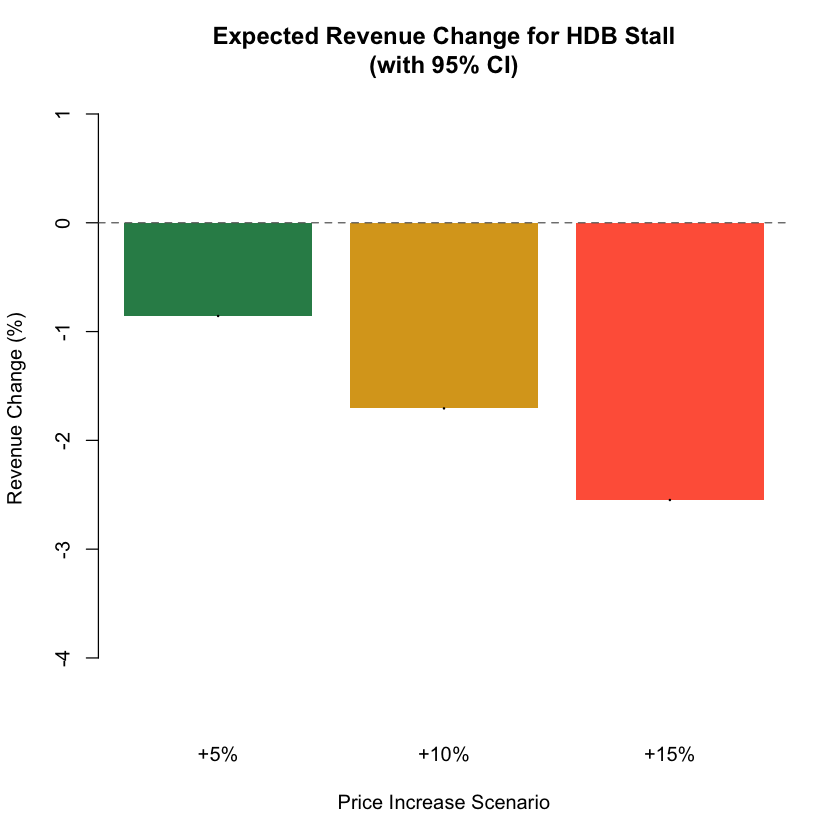

In [90]:
par(bg = "white")
# --- Bar chart with CI error bars (HDB stall) ---
means  <- c(mean(pct_change_5), mean(pct_change_10), mean(pct_change_15))
lowers <- c(
  mean(pct_change_5)  - qt(0.975, n_sim-1) * sd(pct_change_5)  / sqrt(n_sim),
  mean(pct_change_10) - qt(0.975, n_sim-1) * sd(pct_change_10) / sqrt(n_sim),
  mean(pct_change_15) - qt(0.975, n_sim-1) * sd(pct_change_15) / sqrt(n_sim)
)
uppers <- c(
  mean(pct_change_5)  + qt(0.975, n_sim-1) * sd(pct_change_5)  / sqrt(n_sim),
  mean(pct_change_10) + qt(0.975, n_sim-1) * sd(pct_change_10) / sqrt(n_sim),
  mean(pct_change_15) + qt(0.975, n_sim-1) * sd(pct_change_15) / sqrt(n_sim)
)

bar_colors <- c("seagreen", "goldenrod", "tomato")

bp <- barplot(means,
              names.arg = c("+5%", "+10%", "+15%"),
              col = bar_colors,
              ylim = c(min(lowers) - 2, max(uppers) + 2),
              main = "Expected Revenue Change for HDB Stall\n(with 95% CI)",
              xlab = "Price Increase Scenario",
              ylab = "Revenue Change (%)",
              border = NA)

arrows(bp, lowers, bp, uppers,
       angle = 90, code = 3, length = 0.1, lwd = 2)

abline(h = 0, lty = 2, col = "gray40")

## Conclusion and Recommendation

**The paradox resolved:** While the raw data suggests higher prices correlate with higher revenue (r = +0.26), this is a classic case of Simpson's Paradox. Location acts as a confounding variable — CBD and Tourist-area stalls naturally charge more *and* earn more. After controlling for location, cuisine, competition, day type, and stall age in a multiple regression, the true price effect is **negative**: each $1 increase in average plate price is associated with approximately a **4.9% decrease** in daily revenue (p = 0.001).

**Simulation results for HDB Chinese stalls** show that:
- A **+5% price increase** (from $3.50 to $3.68) results in a modest revenue decline, with the 95% CI still close to zero — suggesting this is a tolerable adjustment.
- A **+10% or +15% increase** leads to progressively larger revenue losses that are statistically distinguishable from zero.

**Recommendation:** For HDB hawker stalls, we recommend **limiting price increases to no more than 5%** at a time. This balances the need to cover rising costs while minimising customer attrition. CBD stalls have more pricing headroom due to their location premium, but should still exercise caution beyond 10%. Any price adjustment should be paired with monitoring of daily revenue trends over the following weeks.